1. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
import kagglehub
import os

2. Load the Dataset

Description:
Loads the cleaned dataset and shows the first few rows.

In [21]:
path = kagglehub.dataset_download("vikaseranki9/mobile-usage-behavioral-analysis-dataset")

print("Path to dataset files:", path)

csv_path = None
for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)
        break

if csv_path is None:
    raise FileNotFoundError(f"No .csv file found in {path}")

df = pd.read_csv(csv_path)
df.head()


print("Initial shape:", df.shape)
print("\nInitial dtypes:\n", df.dtypes)

Path to dataset files: /Users/saivikas/.cache/kagglehub/datasets/vikaseranki9/mobile-usage-behavioral-analysis-dataset/versions/1
Initial shape: (1000, 10)

Initial dtypes:
 User_ID                           int64
Age                               int64
Gender                           object
Total_App_Usage_Hours           float64
Daily_Screen_Time_Hours         float64
Number_of_Apps_Used               int64
Social_Media_Usage_Hours        float64
Productivity_App_Usage_Hours    float64
Gaming_App_Usage_Hours          float64
Location                         object
dtype: object


3. Visualize Basic Feature Distributions

Description:
Shows the distribution of key usage behaviors (screen time, apps used, etc.).

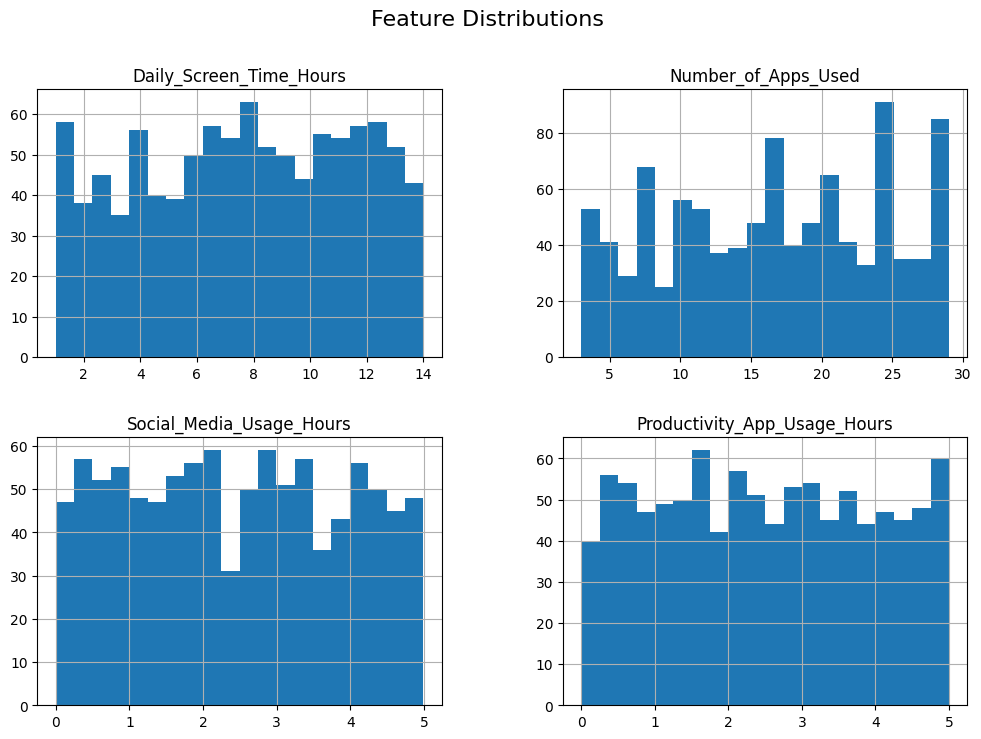

In [22]:
df[[
    "Daily_Screen_Time_Hours",
    "Number_of_Apps_Used",
    "Social_Media_Usage_Hours",
    "Productivity_App_Usage_Hours"
]].hist(bins=20, figsize=(12, 8))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


4. Create Efficiency Score + Label Users

Description:

Creates an efficiency metric.
Labels users into 3 categories (efficient, inefficient, neutral).
Drops neutral for clean binary prediction.

In [23]:
df["efficiency_score"] = (
    df["Productivity_App_Usage_Hours"] /
    df["Daily_Screen_Time_Hours"].replace(0, np.nan)
).fillna(0)

low = df["efficiency_score"].quantile(0.33)
high = df["efficiency_score"].quantile(0.67)

def label_user(x):
    if x <= low:
        return 0  # inefficient
    elif x >= high:
        return 1  # efficient
    else:
        return 2  # neutral

df["label"] = df["efficiency_score"].apply(label_user)

df2 = df[df["label"] != 2].copy()
df2["y"] = df2["label"]

df2["y"].value_counts()


y
0    330
1    330
Name: count, dtype: int64

5. Correlation Heatmap

Description:
Shows how numeric features relate to each other.

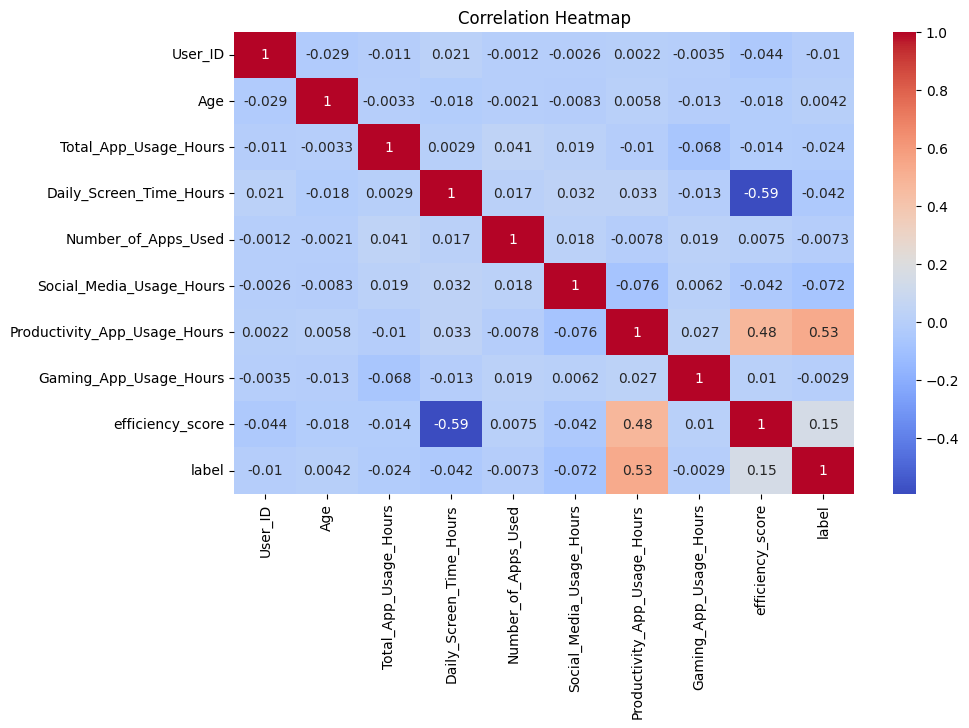

In [24]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


6. Select Features (No Leakage)

Description:
Chooses input features and sets up scaling + one-hot encoding.

In [25]:
features = [
    "Age",
    "Daily_Screen_Time_Hours",
    "Number_of_Apps_Used",
    "Social_Media_Usage_Hours",
    "Gaming_App_Usage_Hours",
    "Gender",
    "Location"
]

X = df2[features]
y = df2["y"]

numeric_features = [
    "Age",
    "Daily_Screen_Time_Hours",
    "Number_of_Apps_Used",
    "Social_Media_Usage_Hours",
    "Gaming_App_Usage_Hours",
]

categorical_features = ["Gender", "Location"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


7. Train/Test Split

Description:
Splits the data into training (80%) and testing (20%).

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


8. Train 3 ML Models

Logistic Regression • Random Forest • Decision Tree

In [27]:
models = {}

models["Logistic Regression"] = Pipeline([
    ("pre", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])
models["Logistic Regression"].fit(X_train, y_train)
log_pred = models["Logistic Regression"].predict(X_test)

models["Random Forest"] = Pipeline([
    ("pre", preprocess),
    ("clf", RandomForestClassifier(n_estimators=150, random_state=42))
])
models["Random Forest"].fit(X_train, y_train)
rf_pred = models["Random Forest"].predict(X_test)

models["Decision Tree"] = Pipeline([
    ("pre", preprocess),
    ("clf", DecisionTreeClassifier(max_depth=5, random_state=42))
])
models["Decision Tree"].fit(X_train, y_train)
dt_pred = models["Decision Tree"].predict(X_test)


9. Display Model Accuracy

In [28]:
print("\n===== MODEL RESULTS =====")
results = {
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred)
}

for name, acc in results.items():
    print(f"{name}: {acc:.4f}")



===== MODEL RESULTS =====
Logistic Regression: 0.8409
Random Forest: 0.8258
Decision Tree: 0.8182


10. Visualize Model Comparison

Description:
A simple accuracy comparison bar chart.

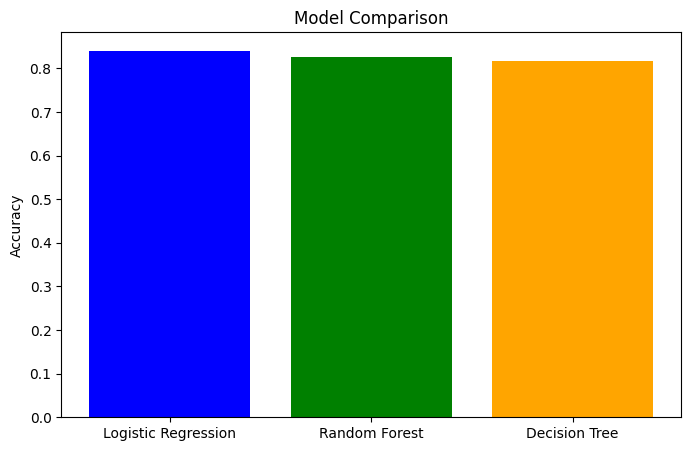

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange'])
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()


11. KMeans Clustering

Description:
Groups users into 3 natural behavior clusters.

In [30]:
cluster_features = [
    "Daily_Screen_Time_Hours",
    "Number_of_Apps_Used",
    "Social_Media_Usage_Hours",
    "Productivity_App_Usage_Hours",
    "Gaming_App_Usage_Hours",
]

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df["cluster"] = kmeans.fit_predict(cluster_scaled)

cluster_summary = df.groupby("cluster")[cluster_features].mean()
cluster_summary


,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours
cluster,,,,,
0,6.948065,15.438710,1.959323,2.814839,4.029774
1,8.095961,17.888579,3.843398,1.850669,2.195181
2,7.963625,16.432024,1.417402,2.895106,1.323595


12. Visualize Cluster Centers (Bar Chart)

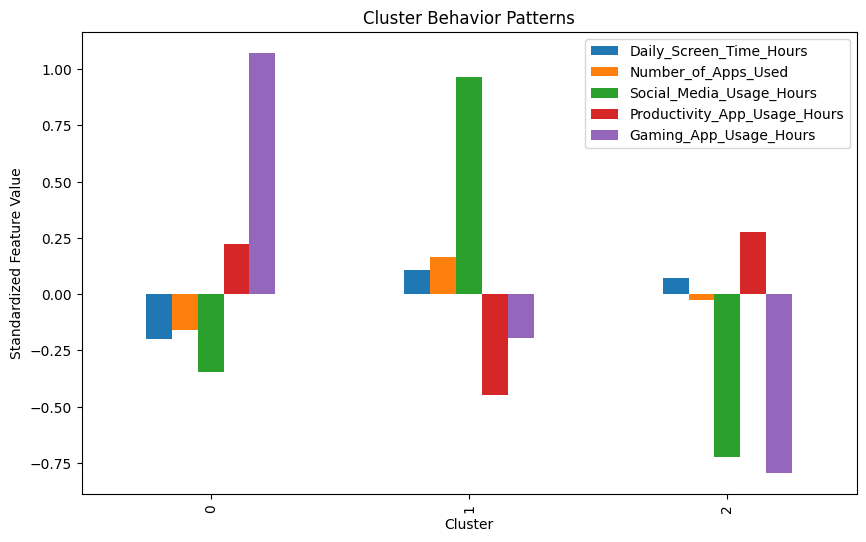

In [31]:
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_features)

cluster_centers.plot(kind="bar", figsize=(10, 6))
plt.title("Cluster Behavior Patterns")
plt.xlabel("Cluster")
plt.ylabel("Standardized Feature Value")
plt.show()


13. PCA Visualization of Clusters (2D Plot)

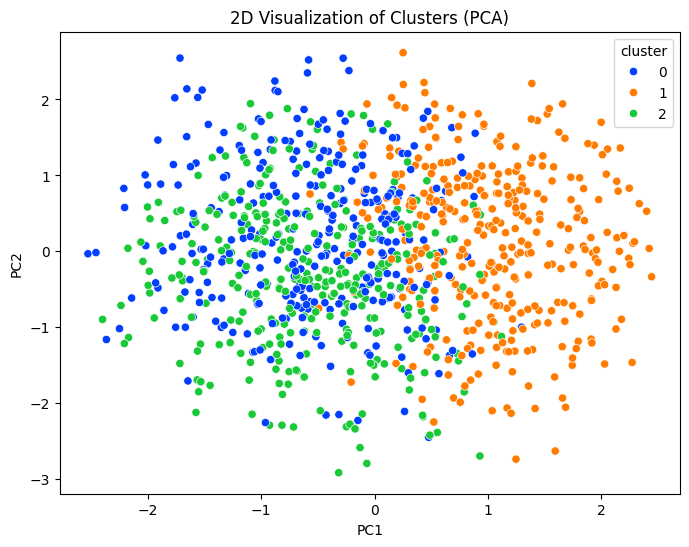

In [32]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(cluster_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pca_data[:, 0],
    y=pca_data[:, 1],
    hue=df["cluster"],
    palette="bright"
)
plt.title("2D Visualization of Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
